# 02: Candidate Corridor Generation

**Purpose**: Define the decision space for optimization - what corridors could be built?

**Why this notebook matters**:
- Optimization requires a **finite, interpretable choice set**
- This notebook answers: **"What are the possible things we could build?"**
- This is **design, not evaluation** - we're not deciding which is best yet

**What this notebook does**:
1. Defines what a "corridor" is (geometry, stop spacing, speed, headway, mode)
2. Generates candidate corridors using explicit heuristics
3. Visualizes all candidates on a map
4. Saves corridors to disk for evaluation in later notebooks

**What this notebook does NOT do**:
- ❌ No accessibility recomputation
- ❌ No scoring or ranking
- ❌ No "best corridor" discussion
- ❌ No evaluation of impact

**Checkpoint artifact**: `candidate_corridors.geojson` + map showing all candidates

**You should be able to point at the map and say: "These are the options we are considering."**


## Part 1: Setup and Data Loading

Load baseline accessibility data from Notebook 01.


In [19]:
import sys
from pathlib import Path

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT / "src"))

import config
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point, LineString
from shapely.ops import linemerge
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")

print(f"✓ Imports loaded")
print(f"Max candidate corridors: {config.MAX_CANDIDATE_CORRIDORS}")
print(f"Default stop spacing: {config.DEFAULT_STOP_SPACING} m")
print(f"Default transit speed: {config.DEFAULT_TRANSIT_SPEED} km/h")


✓ Imports loaded
Max candidate corridors: 50
Default stop spacing: 400 m
Default transit speed: 20 km/h


In [20]:
# Load baseline accessibility data from Notebook 01
print("Loading baseline accessibility data...")

baseline_path = config.DATA_PROCESSED / "baseline_accessibility.parquet"
if baseline_path.exists():
    baseline = gpd.read_parquet(baseline_path)
    print(f"  ✓ Loaded baseline accessibility: {len(baseline):,} tracts")
else:
    # Fallback: try GeoJSON
    baseline_path = config.DATA_PROCESSED / "baseline_accessibility.geojson"
    if baseline_path.exists():
        baseline = gpd.read_file(baseline_path)
        print(f"  ✓ Loaded baseline accessibility: {len(baseline):,} tracts")
    else:
        raise FileNotFoundError("Baseline accessibility data not found. Run Notebook 01 first.")

# Ensure we have required columns
required_cols = ['GEOID', 'geometry', 'accessibility_baseline', 'jobs_total', 'pop_total']
missing_cols = [c for c in required_cols if c not in baseline.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

print(f"  Tracts with accessibility data: {baseline['accessibility_baseline'].notna().sum():,}")
print(f"  Tracts with jobs: {baseline['jobs_total'].notna().sum():,}")
print(f"  Tracts with population: {baseline['pop_total'].notna().sum():,}")


Loading baseline accessibility data...
  ✓ Loaded baseline accessibility: 2,498 tracts
  Tracts with accessibility data: 2,498
  Tracts with jobs: 2,494
  Tracts with population: 2,498


## Part 2: Corridor Definition

**This section explicitly defines what a "corridor" is. This definition is FROZEN.**


### What is a Transit Corridor?

A **transit corridor** is a synthetic transit line defined by the following attributes:

1. **Geometry**: A polyline (LineString) representing the route path
   - Connects origin point to destination point
   - Straight-line or follows major arterial roads (simplified)

2. **Stop Spacing**: Distance between consecutive stops
   - **Default**: 400 meters
   - This is BRT-like spacing (typical for bus rapid transit)
   - Stops are placed evenly along the corridor

3. **Transit Speed**: Average operating speed
   - **Default**: 20 km/h (~12.4 mph)
   - This is typical for bus service in urban areas
   - Accounts for stops, traffic, and signal delays

4. **Headway**: Time between consecutive vehicles
   - **Default**: 10 minutes
   - **Note**: Headway is for documentation only; it does not affect accessibility calculations
   - Represents service frequency

5. **Mode Abstraction**: Type of service
   - **Default**: BRT-like (Bus Rapid Transit)
   - Characteristics: Dedicated lanes (assumed), signal priority (assumed), high-frequency service
   - This is an abstraction - actual implementation could be bus, rail, or BRT

**Why these parameters?**
- **Stop spacing (400m)**: Balances walkability (shorter = better) with speed (fewer stops = faster)
- **Speed (20 km/h)**: Realistic for urban transit with stops
- **Headway (10 min)**: Represents high-frequency service (typical for major corridors)
- **BRT-like**: Represents a high-quality transit service without requiring rail infrastructure

**This definition is FROZEN** - all corridors use the same parameters for fair comparison.


## Part 3: Candidate Generation Strategies

Generate candidate corridors using explicit heuristics. These are **design rules**, not optimization.

**Heuristic Strategies**:

1. **Transit Desert → Job Center**: Connect low-accessibility tracts to high-job-density tracts
2. **High-Pop → High-Job**: Connect high-population tracts to high-job-density tracts
3. **Existing Arterial Alignment**: Follow major roads (simplified as straight lines between key points)

**Limits**:
- **Maximum**: 50 corridors (from `config.MAX_CANDIDATE_CORRIDORS`)
- **Minimum**: 20 corridors (from `config.MIN_CANDIDATE_CORRIDORS`)
- If heuristics generate more than max, prioritize by:
  - Strategy 1 (desert → job center) first
  - Then Strategy 2 (high-pop → high-job)
  - Then Strategy 3 (arterial alignment)


In [21]:
# Step 1: Identify transit deserts (low accessibility tracts)
print("Identifying transit deserts and job centers...")

# Project to UTM for accurate centroid calculation
baseline_proj = baseline.to_crs(config.ANALYSIS_CRS)
baseline_proj['centroid'] = baseline_proj.geometry.centroid
baseline_proj['centroid_lon'] = baseline_proj.to_crs(config.GEOGRAPHIC_CRS).geometry.centroid.x
baseline_proj['centroid_lat'] = baseline_proj.to_crs(config.GEOGRAPHIC_CRS).geometry.centroid.y

# Transit deserts: bottom 20% of accessibility (or zero accessibility)
accessibility_valid = baseline_proj['accessibility_baseline'].dropna()
if len(accessibility_valid) > 0:
    desert_threshold = accessibility_valid.quantile(0.20)  # Bottom 20%
    baseline_proj['is_desert'] = (baseline_proj['accessibility_baseline'] <= desert_threshold) | (baseline_proj['accessibility_baseline'] == 0)
else:
    baseline_proj['is_desert'] = baseline_proj['accessibility_baseline'] == 0

deserts = baseline_proj[baseline_proj['is_desert']].copy()
print(f"  ✓ Identified {len(deserts):,} transit desert tracts (bottom 20% or zero accessibility)")

# Job centers: top 20% of job density
jobs_valid = baseline_proj['jobs_total'].dropna()
if len(jobs_valid) > 0:
    job_center_threshold = jobs_valid.quantile(0.80)  # Top 20%
    baseline_proj['is_job_center'] = baseline_proj['jobs_total'] >= job_center_threshold
else:
    baseline_proj['is_job_center'] = False

job_centers = baseline_proj[baseline_proj['is_job_center']].copy()
print(f"  ✓ Identified {len(job_centers):,} job center tracts (top 20% job density)")

# High-population tracts: top 20% of population
pop_valid = baseline_proj['pop_total'].dropna()
if len(pop_valid) > 0:
    high_pop_threshold = pop_valid.quantile(0.80)  # Top 20%
    baseline_proj['is_high_pop'] = baseline_proj['pop_total'] >= high_pop_threshold
else:
    baseline_proj['is_high_pop'] = False

high_pop = baseline_proj[baseline_proj['is_high_pop']].copy()
print(f"  ✓ Identified {len(high_pop):,} high-population tracts (top 20% population)")


Identifying transit deserts and job centers...
  ✓ Identified 576 transit desert tracts (bottom 20% or zero accessibility)
  ✓ Identified 499 job center tracts (top 20% job density)
  ✓ Identified 500 high-population tracts (top 20% population)


In [22]:
# Step 2: Generate candidate corridors using heuristics
print(f"\nGenerating candidate corridors (max {config.MAX_CANDIDATE_CORRIDORS})...")

corridors = []

# Strategy 1: Transit Desert → Job Center
print("  Strategy 1: Transit Desert → Job Center")
strategy1_count = 0
max_per_strategy = config.MAX_CANDIDATE_CORRIDORS // 3  # Roughly equal distribution

for desert_idx, desert_row in deserts.iterrows():
    if strategy1_count >= max_per_strategy:
        break
    
    # Find nearest job center to this desert
    desert_point = Point(desert_row['centroid_lon'], desert_row['centroid_lat'])
    job_center_points = [Point(lon, lat) for lon, lat in zip(job_centers['centroid_lon'], job_centers['centroid_lat'])]
    
    # Calculate distances
    distances = [desert_point.distance(jc_point) for jc_point in job_center_points]
    nearest_jc_idx = np.argmin(distances)
    nearest_jc = job_centers.iloc[nearest_jc_idx]
    
    # Create corridor (straight line between desert and job center)
    corridor_line = LineString([
        (desert_row['centroid_lon'], desert_row['centroid_lat']),
        (nearest_jc['centroid_lon'], nearest_jc['centroid_lat'])
    ])
    
    corridors.append({
        'corridor_id': f'C{strategy1_count+1:03d}',
        'strategy': 'desert_to_job_center',
        'origin_geoid': desert_row['GEOID'],
        'dest_geoid': nearest_jc['GEOID'],
        'geometry': corridor_line,
        'stop_spacing_m': config.DEFAULT_STOP_SPACING,
        'speed_kmh': config.DEFAULT_TRANSIT_SPEED,
        'headway_min': config.DEFAULT_HEADWAY,
        'mode': 'BRT-like',
        'length_m': corridor_line.length * 111000  # Approximate: degrees to meters
    })
    strategy1_count += 1

print(f"    ✓ Generated {strategy1_count} corridors")

# Strategy 2: High-Pop → High-Job
print("  Strategy 2: High-Population → High-Job")
strategy2_count = 0

for pop_idx, pop_row in high_pop.iterrows():
    if strategy2_count >= max_per_strategy or len(corridors) >= config.MAX_CANDIDATE_CORRIDORS:
        break
    
    # Find nearest job center to this high-pop tract
    pop_point = Point(pop_row['centroid_lon'], pop_row['centroid_lat'])
    job_center_points = [Point(lon, lat) for lon, lat in zip(job_centers['centroid_lon'], job_centers['centroid_lat'])]
    
    distances = [pop_point.distance(jc_point) for jc_point in job_center_points]
    nearest_jc_idx = np.argmin(distances)
    nearest_jc = job_centers.iloc[nearest_jc_idx]
    
    # Create corridor
    corridor_line = LineString([
        (pop_row['centroid_lon'], pop_row['centroid_lat']),
        (nearest_jc['centroid_lon'], nearest_jc['centroid_lat'])
    ])
    
    corridors.append({
        'corridor_id': f'C{len(corridors)+1:03d}',
        'strategy': 'high_pop_to_job',
        'origin_geoid': pop_row['GEOID'],
        'dest_geoid': nearest_jc['GEOID'],
        'geometry': corridor_line,
        'stop_spacing_m': config.DEFAULT_STOP_SPACING,
        'speed_kmh': config.DEFAULT_TRANSIT_SPEED,
        'headway_min': config.DEFAULT_HEADWAY,
        'mode': 'BRT-like',
        'length_m': corridor_line.length * 111000
    })
    strategy2_count += 1

print(f"    ✓ Generated {strategy2_count} corridors")

# Strategy 3: Connect major job centers to each other
print("  Strategy 3: Job Center → Job Center")
strategy3_count = 0

# Connect top job centers to each other (up to limit)
top_job_centers = job_centers.nlargest(10, 'jobs_total')  # Top 10 job centers

for i, jc1 in top_job_centers.iterrows():
    if len(corridors) >= config.MAX_CANDIDATE_CORRIDORS:
        break
    
    for j, jc2 in top_job_centers.iterrows():
        if i >= j or len(corridors) >= config.MAX_CANDIDATE_CORRIDORS:
            continue
        
        # Create corridor between job centers
        corridor_line = LineString([
            (jc1['centroid_lon'], jc1['centroid_lat']),
            (jc2['centroid_lon'], jc2['centroid_lat'])
        ])
        
        corridors.append({
            'corridor_id': f'C{len(corridors)+1:03d}',
            'strategy': 'job_center_to_job_center',
            'origin_geoid': jc1['GEOID'],
            'dest_geoid': jc2['GEOID'],
            'geometry': corridor_line,
            'stop_spacing_m': config.DEFAULT_STOP_SPACING,
            'speed_kmh': config.DEFAULT_TRANSIT_SPEED,
            'headway_min': config.DEFAULT_HEADWAY,
            'mode': 'BRT-like',
            'length_m': corridor_line.length * 111000
        })
        strategy3_count += 1

print(f"    ✓ Generated {strategy3_count} corridors")

# Limit to max corridors if exceeded
if len(corridors) > config.MAX_CANDIDATE_CORRIDORS:
    corridors = corridors[:config.MAX_CANDIDATE_CORRIDORS]
    print(f"  ⚠ Limited to {config.MAX_CANDIDATE_CORRIDORS} corridors (max limit)")

print(f"\n✓ Generated {len(corridors):,} candidate corridors")
print(f"  Strategy 1 (desert→job): {sum(1 for c in corridors if c['strategy'] == 'desert_to_job_center')}")
print(f"  Strategy 2 (pop→job): {sum(1 for c in corridors if c['strategy'] == 'high_pop_to_job')}")
print(f"  Strategy 3 (job→job): {sum(1 for c in corridors if c['strategy'] == 'job_center_to_job_center')}")



Generating candidate corridors (max 50)...
  Strategy 1: Transit Desert → Job Center
    ✓ Generated 16 corridors
  Strategy 2: High-Population → High-Job
    ✓ Generated 16 corridors
  Strategy 3: Job Center → Job Center
    ✓ Generated 18 corridors

✓ Generated 50 candidate corridors
  Strategy 1 (desert→job): 16
  Strategy 2 (pop→job): 16
  Strategy 3 (job→job): 18


In [23]:
# Step 3: Create GeoDataFrame of corridors
print("Creating corridor GeoDataFrame...")

corridors_gdf = gpd.GeoDataFrame(corridors, crs=config.GEOGRAPHIC_CRS)

# Calculate number of stops for each corridor
corridors_gdf['num_stops'] = (corridors_gdf['length_m'] / corridors_gdf['stop_spacing_m']).astype(int) + 1  # +1 for endpoints

# Summary statistics
print(f"  ✓ Created GeoDataFrame with {len(corridors_gdf):,} corridors")
print(f"\n  Corridor Statistics:")
print(f"    Mean length: {corridors_gdf['length_m'].mean()/1000:.2f} km")
print(f"    Median length: {corridors_gdf['length_m'].median()/1000:.2f} km")
print(f"    Min length: {corridors_gdf['length_m'].min()/1000:.2f} km")
print(f"    Max length: {corridors_gdf['length_m'].max()/1000:.2f} km")
print(f"    Mean stops per corridor: {corridors_gdf['num_stops'].mean():.1f}")
print(f"    Total stops across all corridors: {corridors_gdf['num_stops'].sum():,}")


Creating corridor GeoDataFrame...
  ✓ Created GeoDataFrame with 50 corridors

  Corridor Statistics:
    Mean length: 11.25 km
    Median length: 3.21 km
    Min length: 0.00 km
    Max length: 55.88 km
    Mean stops per corridor: 28.7
    Total stops across all corridors: 1,435


In [24]:
# Step 4: Save corridors to disk
print("Saving candidate corridors...")

config.DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
config.OUTPUTS_FIGURES.mkdir(parents=True, exist_ok=True)

# Save as GeoJSON
output_path = config.DATA_PROCESSED / "candidate_corridors.geojson"
corridors_gdf.to_file(output_path, driver='GeoJSON')
print(f"  ✓ Saved to {output_path.relative_to(config.ROOT)}")

# Also save as CSV (without geometry) for easy inspection
output_csv = config.DATA_PROCESSED / "candidate_corridors.csv"
corridors_gdf.drop(columns=['geometry']).to_csv(output_csv, index=False)
print(f"  ✓ Saved summary to {output_csv.relative_to(config.ROOT)}")

print(f"\n✓ Candidate corridor generation complete!")
print(f"  Total corridors: {len(corridors_gdf):,}")
print(f"  These corridors will be evaluated in Notebook 03 (Counterfactual Accessibility)")


Saving candidate corridors...
  ✓ Saved to data_processed/candidate_corridors.geojson
  ✓ Saved summary to data_processed/candidate_corridors.csv

✓ Candidate corridor generation complete!
  Total corridors: 50
  These corridors will be evaluated in Notebook 03 (Counterfactual Accessibility)


## Part 4: Visualization

Create a map showing all candidate corridors. This is the **decision space** - the options we are considering.


Creating candidate corridors map...
  ✓ Saved to outputs/figures/candidate_corridors_map.png


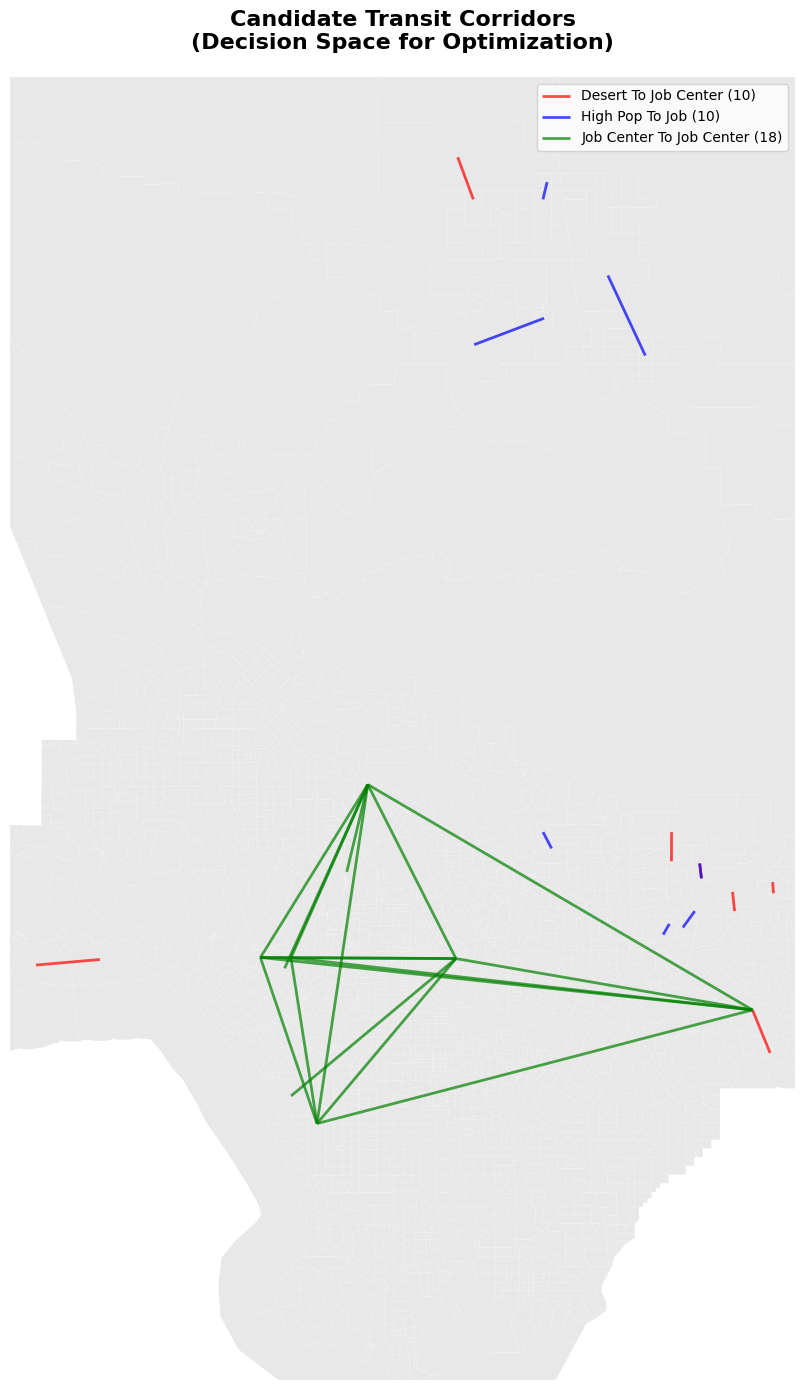


✓ Visualization complete!
  This map shows all 38 candidate corridors.
  These are the options we are considering - no ranking or evaluation yet.


In [25]:
# Create map of all candidate corridors
print("Creating candidate corridors map...")

# Filter to LA County extent
la_bbox = {'min_lon': -118.7, 'max_lon': -117.9, 'min_lat': 33.7, 'max_lat': 34.8}
baseline_map = baseline.to_crs(config.GEOGRAPHIC_CRS)
baseline_map = baseline_map.cx[la_bbox['min_lon']:la_bbox['max_lon'], la_bbox['min_lat']:la_bbox['max_lat']]
corridors_map = corridors_gdf.to_crs(config.GEOGRAPHIC_CRS)
corridors_map = corridors_map.cx[la_bbox['min_lon']:la_bbox['max_lon'], la_bbox['min_lat']:la_bbox['max_lat']]

# Create figure
fig, ax = plt.subplots(figsize=(16, 14))

# Plot tracts as background
baseline_map.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.2, alpha=0.5)

# Plot corridors by strategy with different colors
strategy_colors = {
    'desert_to_job_center': 'red',
    'high_pop_to_job': 'blue',
    'job_center_to_job_center': 'green'
}

for strategy, color in strategy_colors.items():
    strategy_corridors = corridors_map[corridors_map['strategy'] == strategy]
    if len(strategy_corridors) > 0:
        strategy_corridors.plot(ax=ax, color=color, linewidth=2, alpha=0.7, 
                               label=f"{strategy.replace('_', ' ').title()} ({len(strategy_corridors)})")

# Set extent and labels
ax.set_xlim(la_bbox['min_lon'], la_bbox['max_lon'])
ax.set_ylim(la_bbox['min_lat'], la_bbox['max_lat'])
ax.set_title('Candidate Transit Corridors\n(Decision Space for Optimization)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.legend(loc='upper right', fontsize=10)
ax.axis('off')

plt.tight_layout()
output_fig_path = config.OUTPUTS_FIGURES / 'candidate_corridors_map.png'
plt.savefig(output_fig_path, dpi=300, bbox_inches='tight')
print(f"  ✓ Saved to {output_fig_path.relative_to(config.ROOT)}")
plt.show()

print(f"\n✓ Visualization complete!")
print(f"  This map shows all {len(corridors_map):,} candidate corridors.")
print(f"  These are the options we are considering - no ranking or evaluation yet.")


## Part 5: Summary and Checkpoint

**This notebook has produced the candidate corridor decision space.**

**Key outputs**:
1. ✅ `candidate_corridors.geojson` - All candidate corridors with attributes
2. ✅ `candidate_corridors_map.png` - Map showing all candidates
3. ✅ `candidate_corridors.csv` - Summary table (without geometry)

**Corridor Attributes** (all corridors have these):
- `corridor_id`: Unique identifier (C001, C002, ...)
- `strategy`: Generation strategy (desert_to_job_center, high_pop_to_job, job_center_to_job_center)
- `geometry`: LineString polyline
- `stop_spacing_m`: 400 m (frozen)
- `speed_kmh`: 20 km/h (frozen)
- `headway_min`: 10 min (frozen)
- `mode`: BRT-like (frozen)
- `length_m`: Corridor length in meters
- `num_stops`: Number of stops along corridor

**Next steps**:
- Notebook 03: Compute counterfactual accessibility for each corridor
- Notebook 04: Rank corridors using objective function
- Notebook 05: Estimate demand for top corridors

**Important**: This is the **decision space**. We have not evaluated or ranked corridors yet - that happens in later notebooks.
